###  Assignment-07-MULTIPLE LINEAR REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
data = pd.read_csv(r"Data\ToyotaCorolla - MLR.csv")
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
data.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [4]:
data.info

<bound method DataFrame.info of       Price  Age_08_04     KM Fuel_Type   HP  Automatic    cc  Doors  \
0     13500         23  46986    Diesel   90          0  2000      3   
1     13750         23  72937    Diesel   90          0  2000      3   
2     13950         24  41711    Diesel   90          0  2000      3   
3     14950         26  48000    Diesel   90          0  2000      3   
4     13750         30  38500    Diesel   90          0  2000      3   
...     ...        ...    ...       ...  ...        ...   ...    ...   
1431   7500         69  20544    Petrol   86          0  1300      3   
1432  10845         72  19000    Petrol   86          0  1300      3   
1433   8500         71  17016    Petrol   86          0  1300      3   
1434   7250         70  16916    Petrol   86          0  1300      3   
1435   6950         76      1    Petrol  110          0  1600      5   

      Cylinders  Gears  Weight  
0             4      5    1165  
1             4      5    1165  
2   

In [5]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
data.shape

(1436, 11)

In [7]:
data.dtypes

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

### Visualize the data

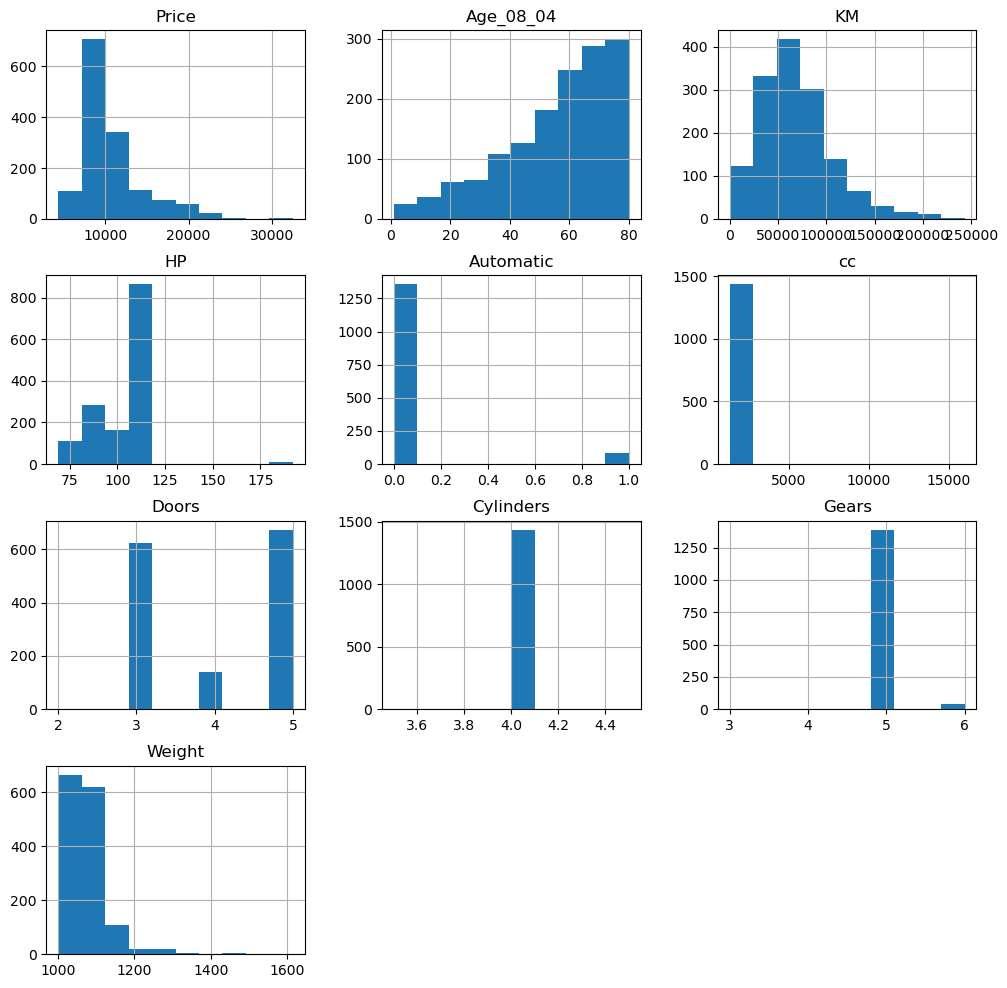

In [8]:
data.hist(figsize=(12,12))
plt.show()

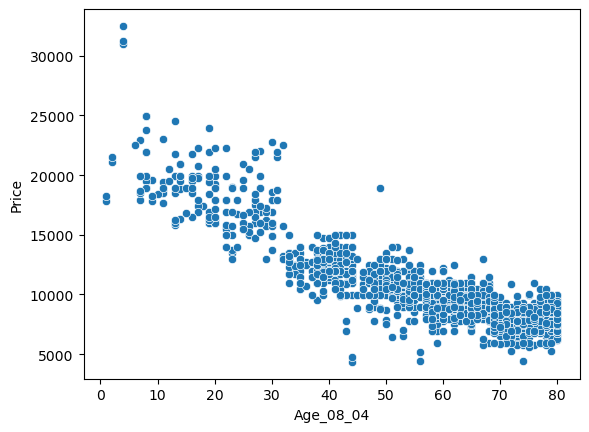

In [9]:
sns.scatterplot(data,
                x='Age_08_04',
                y='Price'
)
plt.show()

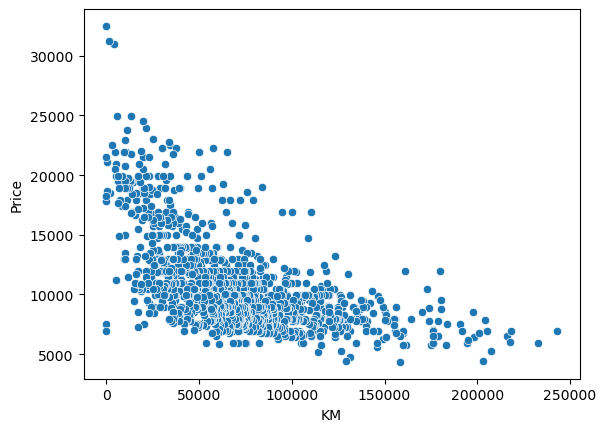

In [10]:
sns.scatterplot(data,
                x='KM',
                y='Price'
)
plt.show()

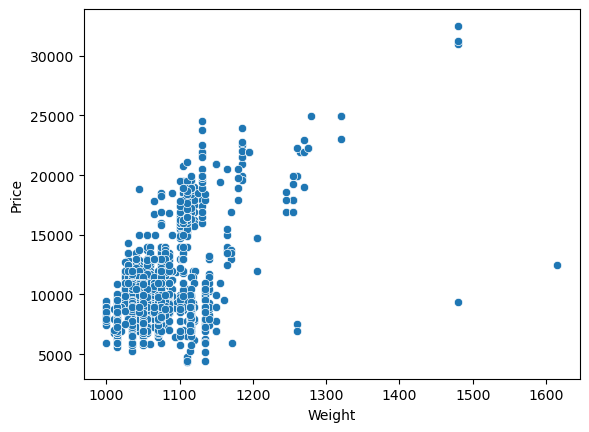

In [11]:
sns.scatterplot(data,
               x='Weight',
               y='Price'
)
plt.show()

### Data Preprocessing

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
# encoding the data
enc = LabelEncoder()
data['Fuel_Type'] = enc.fit_transform(data['Fuel_Type'])
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
# scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns, index=data.index)
scaled_data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.763763,-1.771966,-0.574695,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
1,0.832715,-1.771966,0.117454,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
2,0.887877,-1.718184,-0.715386,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
3,1.163685,-1.610620,-0.547650,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.758561
4,0.832715,-1.395491,-0.801028,-2.337868,-0.768042,-0.242893,0.997419,-1.085139,0.0,-0.140425,1.853577


### Split the data

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X= data.drop('Price', axis=1)
y= data['Price']

#### Model-1

In [56]:
model.coef_

array([-1.21436240e+02, -1.69355966e-02,  8.62056431e+02,  2.06582831e+01,
        2.45196891e+02, -7.35153881e-02, -3.62796477e+01, -3.41060513e-13,
        5.30282040e+02,  2.35106426e+01])

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1148, 10), (288, 10), (1148,), (288,))

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [65]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
yhat_test = model.predict(X_test)

#### Model-2

In [62]:
model2.coef_

array([-1.21444452e+02, -1.67049436e-02,  8.59598131e+02,  2.21573441e+01,
        2.01799851e+02, -7.03368514e-02,  2.33059004e+01])

In [24]:
X2 = data[['Age_08_04','KM','Fuel_Type','HP','Automatic','cc','Weight']]

In [25]:
X_train2,X_test2,y_train2,y_test2 = train_test_split(X2,y,test_size=0.2,random_state=42)
X_train2.shape,X_test2.shape,y_train2.shape,y_test2.shape

((1148, 7), (288, 7), (1148,), (288,))

In [26]:
model2 = LinearRegression()
model2.fit(X_train2,y_train2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Model-3

In [63]:
model3.coef_

array([-1.20025405e+02, -2.02325920e-02,  2.90521704e+01,  1.97690662e+01])

In [59]:
X3 = data[['Age_08_04','KM','HP','Weight']]

In [60]:
X_train3,X_test3,y_train3,y_test3 = train_test_split(X3,y,test_size=0.2,random_state=42)
X_train3.shape,X_test3.shape,y_train3.shape,y_test3.shape

((1148, 4), (288, 4), (1148,), (288,))

In [61]:
model3 = LinearRegression()
model3.fit(X_train3,y_train3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Training Data for models

In [94]:
#model 1
yhat_train = model.predict(X_train)

In [98]:
# evaluation of model
mse =  mean_squared_error(y_train,yhat_train)
rmse = np.sqrt(mse)
r2_sqr =  r2_score(y_train,yhat_train)

print(f'mse : {np.round(mse,2)}')
print(f'rmse : {np.round(rmse,2)}')
print(f'r2 : {np.round(r2_sqr,2)}')

mse : 1718526.28
rmse : 1310.93
r2 : 0.87


In [99]:
# model2
yhat_train2 = model2.predict(X_train2)

In [100]:
# evaluation of model
mse =  mean_squared_error(y_train2,yhat_train2)
rmse = np.sqrt(mse)
r2_sqr =  r2_score(y_train2,yhat_train2)

print(f'mse : {np.round(mse,2)}')
print(f'rmse : {np.round(rmse,2)}')
print(f'r2 : {np.round(r2_sqr,2)}')

mse : 1721535.62
rmse : 1312.07
r2 : 0.87


In [97]:
#model 3
yhat_train3 = model3.predict(X_train3)

In [101]:
# evaluation of model
mse = mean_squared_error(y_train3, yhat_train3)
rmse = np.sqrt(mse)
r2_sqr = r2_score(y_train3, yhat_train3)

print(f"MSE : {np.round(mse,2)}")
print(f"RMSE : {np.round(rmse,2)}")
print(f"R2 : {np.round(r2_sqr,2)}")

MSE : 1776992.83
RMSE : 1333.04
R2 : 0.86


### Testing data for models

In [34]:
# model 1
yhat_test = model.predict(X_test)

In [35]:
# evaluation of model
mse =  mean_squared_error(y_test,yhat_test)
rmse = np.sqrt(mse)
r2_sqr =  r2_score(y_test,yhat_test)

print(f'mse : {np.round(mse,2)}')
print(f'rmse : {np.round(rmse,2)}')
print(f'r2 : {np.round(r2_sqr,2)}')

mse : 2096851.14
rmse : 1448.05
r2 : 0.84


In [ ]:
# model 2
yhat_test2 = model2.predict(X_test2)

In [52]:
# evaluation of model
mse =  mean_squared_error(y_test2,yhat_test2)
rmse = np.sqrt(mse)
r2_sqr =  r2_score(y_test2,yhat_test2)

print(f'mse : {np.round(mse,2)}')
print(f'rmse : {np.round(rmse,2)}')
print(f'r2 : {np.round(r2_sqr,2)}')

mse : 2119618.18
rmse : 1455.89
r2 : 0.84


In [102]:
# model 3
yhat_test3 = model3.predict(X_test3)

In [54]:
# evaluation of model
mse = mean_squared_error(y_test3, yhat_test3)
rmse = np.sqrt(mse)
r2_sqr = r2_score(y_test3, yhat_test3)

print(f"MSE : {np.round(mse,2)}")
print(f"RMSE : {np.round(rmse,2)}")
print(f"R2 : {np.round(r2_sqr,2)}")

MSE : 1993321.01
RMSE : 1411.85
R2 : 0.85


#### Lasso and Ridge

In [66]:
from sklearn.preprocessing import StandardScaler

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Lasso and Ridge

In [87]:
from sklearn.linear_model import Lasso, Ridge

In [88]:
lasso = Lasso(alpha=1.0)
lasso.fit(X,y)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [89]:
params['Lasso'] = lasso.coef_
params

,LinearReg,Lasso,Ridge
Age_08_04,-1.237829e+02,-123.718956,-123.767111
KM,-1.753825e-02,-0.017596,-0.017556
Fuel_Type,5.777178e+02,563.426274,571.905740
HP,2.366908e+01,23.872242,23.759241
Automatic,3.020992e+02,281.674537,297.595986
cc,-5.693481e-02,-0.057294,-0.057254
Doors,-2.991783e+01,-29.596623,-30.237307
Cylinders,1.307399e-12,0.000000,0.000000
Gears,6.220168e+02,590.696649,608.742827
Weight,2.077316e+01,20.732730,20.757106


In [90]:
ridge = Ridge(alpha=1.0)
ridge.fit(X,y)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [91]:
ridge.coef_

array([-1.23767111e+02, -1.75562431e-02,  5.71905740e+02,  2.37592410e+01,
        2.97595986e+02, -5.72539298e-02, -3.02373067e+01,  0.00000000e+00,
        6.08742827e+02,  2.07571057e+01])

In [92]:
params['Ridge'] = ridge.coef_
params

,LinearReg,Lasso,Ridge
Age_08_04,-1.237829e+02,-123.718956,-123.767111
KM,-1.753825e-02,-0.017596,-0.017556
Fuel_Type,5.777178e+02,563.426274,571.905740
HP,2.366908e+01,23.872242,23.759241
Automatic,3.020992e+02,281.674537,297.595986
cc,-5.693481e-02,-0.057294,-0.057254
Doors,-2.991783e+01,-29.596623,-30.237307
Cylinders,1.307399e-12,0.000000,0.000000
Gears,6.220168e+02,590.696649,608.742827
Weight,2.077316e+01,20.732730,20.757106


#### Interview Questions: 

##### 1.What is Normalization & Standardization and how is it helpful?

##### 2.What techniques can be used to address multicollinearity in multiple linear regression?